In [1]:
import copernicusmarine

In [2]:
%%time
ds = copernicusmarine.open_dataset(dataset_id='cmems_mod_med_phy-cur_my_4.2km_P1D-m')

INFO - 2026-04-23T14:26:05Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username:

  rporrino


Copernicus Marine password:

  ········


INFO - 2026-04-23T14:26:35Z - Selected dataset version: "202511"
INFO - 2026-04-23T14:26:35Z - Selected dataset part: "default"


CPU times: user 3.86 s, sys: 748 ms, total: 4.61 s
Wall time: 35.8 s


In [3]:
# Gulf of Lion bounding box
lon_min, lon_max = 2.0, 7.5
lat_min, lat_max = 41.0, 44.5

dates = ["2026-03-21", "2026-03-31"]
uvs = []
for date in dates:
    uv = (
        ds[["uo", "vo"]]
        .sel(time=date, method="nearest")
        .isel(depth=0)
        .sel(longitude=slice(lon_min, lon_max), latitude=slice(lat_min, lat_max))
    )
    uvs.append(uv)

2026-03-21  |  Speed min: 0.0012 m/s  max: 0.7791 m/s
2026-03-31  |  Speed min: 0.0014 m/s  max: 0.9609 m/s


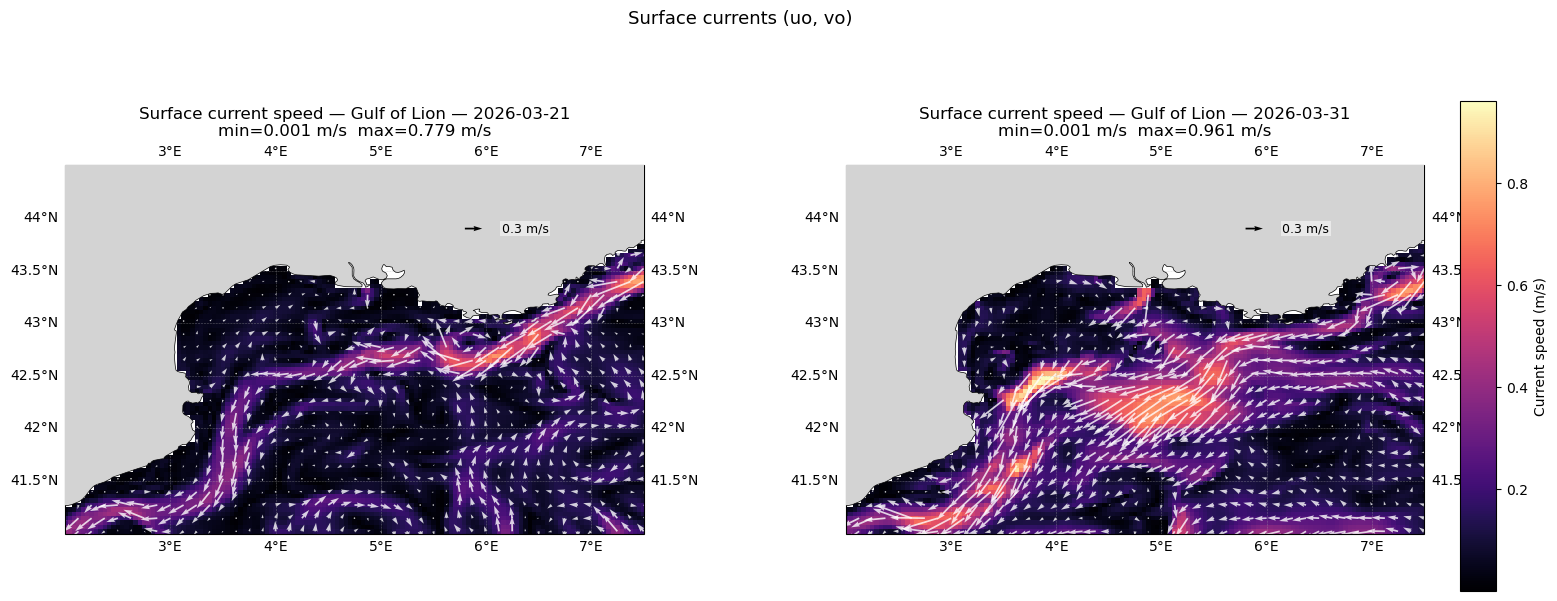

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

ref_speed = 0.3
step = 3

# Compute global vmin/vmax across both dates for a consistent colorscale
speeds = [np.sqrt(uv["uo"]**2 + uv["vo"]**2) for uv in uvs]
vmin = float(min(np.nanmin(s) for s in speeds))
vmax = float(max(np.nanmax(s) for s in speeds))

fig, axes = plt.subplots(1, 2, figsize=(18, 7),
                         subplot_kw={"projection": ccrs.PlateCarree()})
fig.subplots_adjust(right=0.88, wspace=0.35)

for ax, uv, speed, date in zip(axes, uvs, speeds, dates):
    uo = uv["uo"]
    vo = uv["vo"]
    speed_min = float(np.nanmin(speed))
    speed_max = float(np.nanmax(speed))
    print(f"{date}  |  Speed min: {speed_min:.4f} m/s  max: {speed_max:.4f} m/s")

    im = ax.pcolormesh(
        uo.longitude, uo.latitude, speed,
        cmap="magma", transform=ccrs.PlateCarree(), vmin=vmin, vmax=vmax,
    )
    ax.quiver(
        uo.longitude.values[::step], uo.latitude.values[::step],
        uo.values[::step, ::step], vo.values[::step, ::step],
        transform=ccrs.PlateCarree(), scale=10, width=0.003, color="white", alpha=0.8,
    )

    # Reference arrow on land (top-right, French Riviera area)
    ref_lon, ref_lat = 5.8, 43.9
    ax.quiver(ref_lon, ref_lat, ref_speed, 0,
              transform=ccrs.PlateCarree(), scale=10, width=0.003,
              color="black", zorder=10)
    ax.text(ref_lon + 0.35, ref_lat, f"{ref_speed} m/s",
            transform=ccrs.PlateCarree(), fontsize=9,
            va="center", ha="left", color="black", zorder=11,
            bbox=dict(facecolor="white", alpha=0.5, edgecolor="none", pad=1))

    ax.add_feature(cfeature.LAND, zorder=5, facecolor="lightgray")
    ax.add_feature(cfeature.COASTLINE, zorder=6, linewidth=0.5)
    ax.gridlines(draw_labels=True, linewidth=0.4, linestyle="--", alpha=0.5)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax.set_title(f"Surface current speed — Gulf of Lion — {date}\nmin={speed_min:.3f} m/s  max={speed_max:.3f} m/s")

cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Current speed (m/s)")
plt.suptitle("Surface currents (uo, vo)", fontsize=13)
plt.show()

CPU times: user 22.7 s, sys: 10.4 s, total: 33.1 s
Wall time: 24.6 s


Traceback (most recent call last):
 File "/srv/conda/envs/notebook/lib/python3.13/site-packages/pyviz_comms/__init__.py", line 341, in _handle_msg
 self._on_msg(msg)
 ~~~~~~~~~~~~^^^^^
 File "/srv/conda/envs/notebook/lib/python3.13/site-packages/panel/viewable.py", line 501, in _on_msg
 doc.unhold()
 ~~~~~~~~~~^^
 File "/srv/conda/envs/notebook/lib/python3.13/site-packages/bokeh/document/document.py", line 817, in unhold
 self.callbacks.unhold()
 ~~~~~~~~~~~~~~~~~~~~~^^
 File "/srv/conda/envs/notebook/lib/python3.13/site-packages/bokeh/document/callbacks.py", line 450, in unhold
 self.trigger_on_change(event)
 ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^
 File "/srv/conda/envs/notebook/lib/python3.13/site-packages/bokeh/document/callbacks.py", line 427, in trigger_on_change
 invoke_with_curdoc(doc, event.callback_invoker)
 ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
 File "/srv/conda/envs/notebook/lib/python3.13/site-packages/bokeh/document/callbacks.py", line 462, in invoke_with_curdoc
 return f()
 File "/srv/conda/envs/notebook/lib/python3.13/site-packages/bokeh/util/callback_manager.py", line 174, in invoke
 callback(attr, old, new)
 ~~~~~~~~^^^^^^^^^^^^^^^^
 File "/srv/conda/envs/notebook/lib/python3.13/site-packages/panel/reactive.py", line 579, in _comm_change
 state._handle_exception(e)
 ~~~~~~~~~~~~~~~~~~~~~~~^^^
 File "/srv/conda/envs/notebook/lib/python3.13/site-packages/panel/io/state.py", line 529, in _handle_exception
 raise exception
 File "/srv/conda/envs/notebook/lib/python3.13/site-packages/panel/reactive.py", line 577, in _comm_change
 self._schedule_change(doc, comm)
 ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^
 File "/srv/conda/envs/notebook/lib/python3.13/site-packages/panel/reactive.py", line 559, in _schedule_change
 self._change_event(doc)
 ~~~~~~~~~~~~~~~~~~^^^^^
 File "/srv/conda/envs/notebook/lib/python3.13/site-packages/panel/reactive.py", line 555, in _change_event
 self._process_events(events)
 ~~~~~~~~~~~~~~~~~~~~^^^^^^^^
 File "/srv/conda/envs/notebook/lib/python3.13/site-packages/panel/widgets/slider.py", line 110, in _process_events
 super()._process_events(events)
 ~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^
 File "/srv/conda/envs/notebook/lib/python3.13/site-packages/panel/reactive.py", line 498, in _process_events
 raise e
 File "/srv/conda/envs/notebook/lib/python3.13/site-packages/panel/reactive.py", line 479, in _process_events
 self.param.update(**self_params)
 ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^
 File "/srv/conda/envs/notebook/lib/python3.13/site-packages/param/parameterized.py", line 2788, in update
 restore = dict(self_._update(arg, **kwargs))
 ~~~~~~~~~~~~~^^^^^^^^^^^^^^^
 File "/srv/conda/envs/notebook/lib/python3.13/site-packages/param/parameterized.py", line 2821, in _update
 self_._batch_call_watchers()
 ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
 File "/srv/conda/envs/notebook/lib/python3.13/site-packages/param/parameterized.py", line 3038, in _batch_call_watchers
 self_._execute_watcher(watcher, events)
 ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
 File "/srv/conda/envs/notebook/lib/python3.13/site-packages/param/parameterized.py", line 3000, in _execute_watcher
 watcher.fn(*args, **kwargs)
 ~~~~~~~~~~^^^^^^^^^^^^^^^^^
 File "/srv/conda/envs/notebook/lib/python3.13/site-packages/panel/widgets/slider.py", line 539, in _sync_value
 setattr(self, event.name, self.values[event.new])
 ~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
 File "/srv/conda/envs/notebook/lib/python3.13/site-packages/param/parameterized.py", line 629, in _f
 instance_param.__set__(obj, val)
 ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^
 File "/srv/conda/envs/notebook/lib/python3.13/site-packages/param/parameterized.py", line 631, in _f
 return f(self, obj, val)
 File "/srv/conda/envs/notebook/lib/python3.13/site-packages/param/parameterized.py", line 1879, in __set__
 obj.param._call_watcher(watcher, event)
 ~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^
 File "/srv/conda/envs/notebook/lib/python3.13/site-packages/param/parameterized.py", line 3018, in _call_watcher
 self_._exe

Column
    [0] DiscreteSlider(name='Date', options=['2026-03-21', ...], value='2026-03-21')
    [1] Matplotlib(Figure, tight=True)
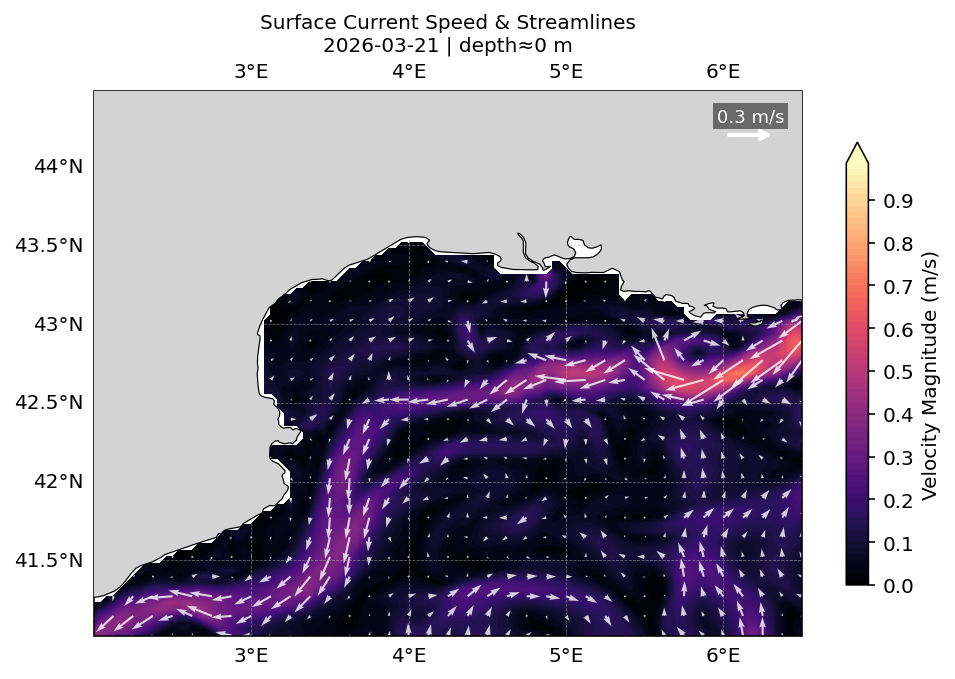

In [5]:
%%time
import panel as pn
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import pandas as pd

pn.extension()

LON = slice(2.0, 6.5)
LAT = slice(41.0, 44.5)
dates = pd.date_range('2026-03-21', '2026-03-31', freq='D')

# --- Pre-carica tutti i dati (21-31 marzo) ---
data_cache = {}
for date in dates:
    date_str = date.strftime('%Y-%m-%d 00:00')
    u = ds['uo'].sel(depth=0, time=date_str, method='nearest').sel(longitude=LON, latitude=LAT).load()
    v = ds['vo'].sel(depth=0, time=date_str, method='nearest').sel(longitude=LON, latitude=LAT).load()
    spd = np.sqrt(u**2 + v**2)
    data_cache[date.strftime('%Y-%m-%d')] = {'u': u, 'v': v, 'spd': spd}

lon = list(data_cache.values())[0]['u'].longitude.values
lat = list(data_cache.values())[0]['u'].latitude.values

# --- Stessi limiti min/max su tutte le date ---
vmin = float(min(d['spd'].min() for d in data_cache.values()))
vmax = float(max(d['spd'].max() for d in data_cache.values()))
levels = np.linspace(vmin, vmax, 70)

# --- Slider ---
date_slider = pn.widgets.DiscreteSlider(
    name='Date', options=list(data_cache.keys()), value=list(data_cache.keys())[0],
)

def make_map(date_str):
    data = data_cache[date_str]
    fig, ax = plt.subplots(figsize=(7, 5), subplot_kw={'projection': ccrs.PlateCarree()})

    cf = ax.contourf(
        lon, lat, data['spd'].values,
        levels=levels, cmap='magma',
        transform=ccrs.PlateCarree(), extend='max',
    )
    cbar = fig.colorbar(cf, ax=ax, label='Velocity Magnitude (m/s)', shrink=0.7)
    cbar.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

    step = 3
    ax.quiver(
        lon[::step], lat[::step],
        data['u'].values[::step, ::step], data['v'].values[::step, ::step],
        transform=ccrs.PlateCarree(), scale=10, width=0.003, color='white', alpha=0.8,
    )

    # --- Vettore di riferimento 0.3 m/s in alto a destra ---
    ref_speed = 0.30
    lon_extent = lon.max() - lon.min()
    arrow_len = (ref_speed / vmax) * lon_extent * 0.25
    ref_lon = lon.max() - arrow_len * 1.5
    ref_lat = lat.max() - (lat.max() - lat.min()) * 0.08

    ax.annotate('',
                xy=(ref_lon + arrow_len, ref_lat),
                xytext=(ref_lon, ref_lat),
                xycoords=ccrs.PlateCarree()._as_mpl_transform(ax),
                textcoords=ccrs.PlateCarree()._as_mpl_transform(ax),
                arrowprops=dict(arrowstyle='->', color='white', lw=2),
                zorder=5)
    ax.text(ref_lon + arrow_len / 2, ref_lat + (lat.max() - lat.min()) * 0.025,
            '0.3 m/s', color='white', ha='center', fontsize=9,
            transform=ccrs.PlateCarree(),
            bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', pad=2),
            zorder=5)

    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=3)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=4)
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, linestyle='--', alpha=0.6)
    gl.right_labels = False
    ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())
    ax.set_title(f'Surface Current Speed & Streamlines\n{date_str} | depth≈0 m', fontsize=10)
    plt.tight_layout()
    plt.close(fig)  # evita doppio rendering inline
    return fig

pn.Column(
    date_slider,
    pn.pane.Matplotlib(pn.bind(make_map, date_str=date_slider), tight=True),
).servable()


In [6]:
app = pn.Column(
    date_slider,
    pn.pane.Matplotlib(pn.bind(make_map, date_str=date_slider), tight=True),
)
app.save('/home/jovyan/MAGICA-School-2026/LAR/currents.html', embed=True)
print('Saved currents.html')

Saved currents.html                            
